# 02 - Exploratory Data Analysis

## E-Commerce Personalization Using EM Clustering and Deep Recommendation

### Objective

This notebook explores the cleaned Online Retail transaction data to
identify important purchasing patterns, customer behaviour, product
characteristics, and relationships that can inform subsequent customer
segmentation and recommendation modelling.

### Key Questions

- What are the main characteristics of the transaction data?
- How do customers differ in purchasing behaviour?
- Which products and countries contribute most to transactions?
- What patterns exist in quantity, spending, and pricing?
- What insights can guide customer segmentation and personalization?

In [13]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
DATA_PATH = "cleaned_data.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (4338, 5)


,CustomerID,NumPurchases,TotalQuantity,TotalSpending,AvgUnitPrice
0,12346.0,1,74215,77183.60,1.040000
1,12347.0,7,2458,4310.00,2.644011
2,12348.0,4,2341,1797.24,5.764839
3,12349.0,1,631,1757.55,8.289041
4,12350.0,1,197,334.40,3.841176


In [14]:
# Exploring the data
print("Rows and columns:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Rows and columns: (4338, 5)

Data types:
CustomerID       float64
NumPurchases       int64
TotalQuantity      int64
TotalSpending    float64
AvgUnitPrice     float64
dtype: object

Missing values:


CustomerID       0
NumPurchases     0
TotalQuantity    0
TotalSpending    0
AvgUnitPrice     0
dtype: int64


Duplicate rows: 0

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
CustomerID,4338.0,15300.408022,1721.808492,12346.0000,13813.250000,15299.500000,16778.750000,18287.00
NumPurchases,4338.0,4.272015,7.697998,1.0000,1.000000,2.000000,5.000000,209.00
TotalQuantity,4338.0,1187.644537,5043.619654,1.0000,159.000000,378.000000,989.750000,196915.00
TotalSpending,4338.0,2048.688081,8985.230220,3.7500,306.482500,668.570000,1660.597500,280206.02
AvgUnitPrice,4338.0,4.470820,34.215024,0.1225,2.206415,2.917836,3.832541,2033.10


In [15]:
# Explore product behavior
top_products = (
    df.groupby("NumPurchases")["TotalQuantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

display(top_products)

NumPurchases
2     422774
1     403544
3     352693
4     339578
6     270825
5     253809
7     244121
73    196915
8     171386
15    158143
Name: TotalQuantity, dtype: int64

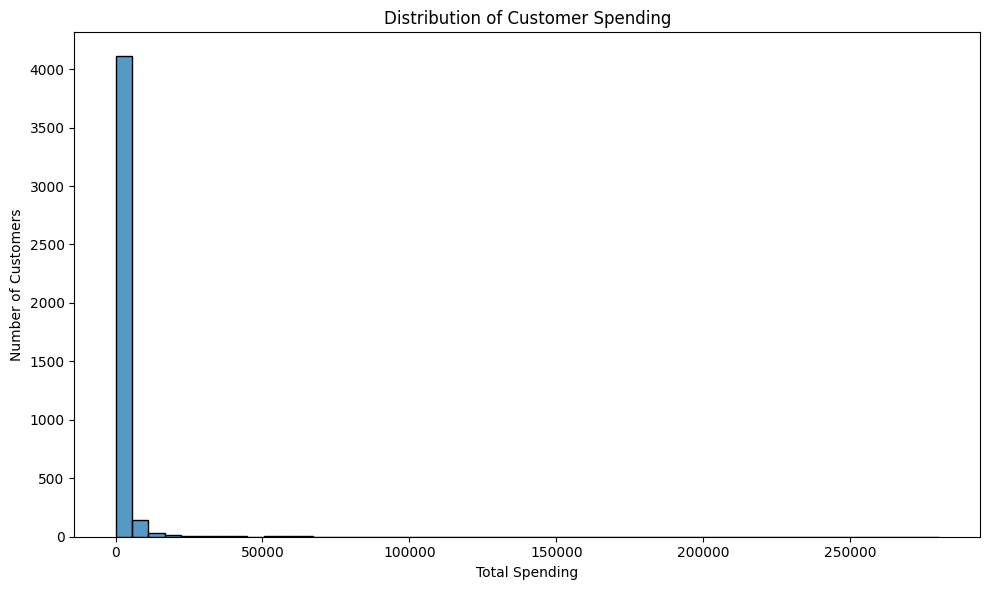

In [17]:
# Spending distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    df["TotalSpending"],
    bins=50
)

plt.title("Distribution of Customer Spending")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.savefig(
    "customer_spending_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

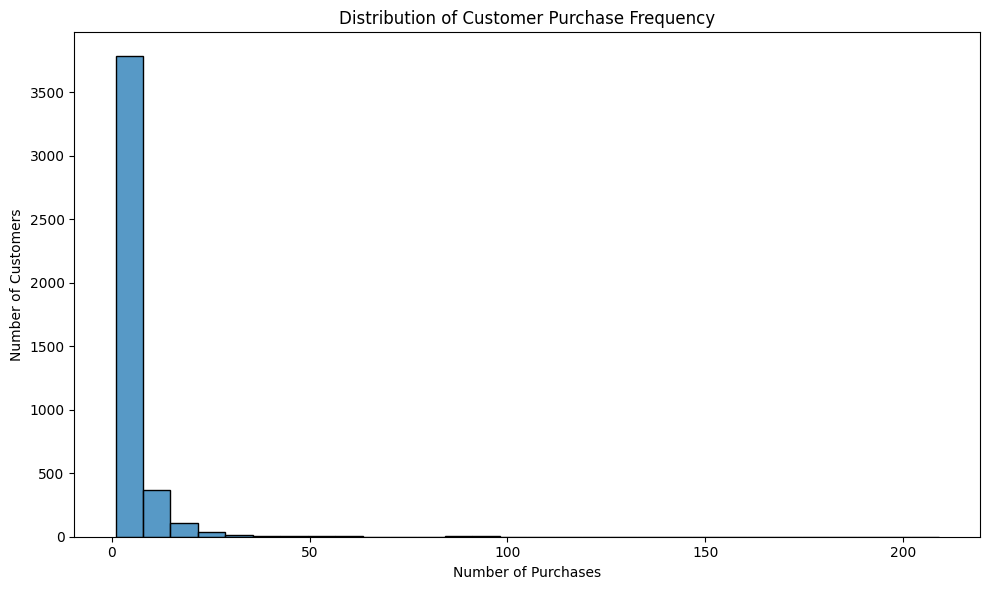

In [18]:
# Purchase Frequency
plt.figure(figsize=(10, 6))

sns.histplot(
    df["NumPurchases"],
    bins=30
)

plt.title("Distribution of Customer Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.savefig(
    "distribution_of_customer_purchase_frequency.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

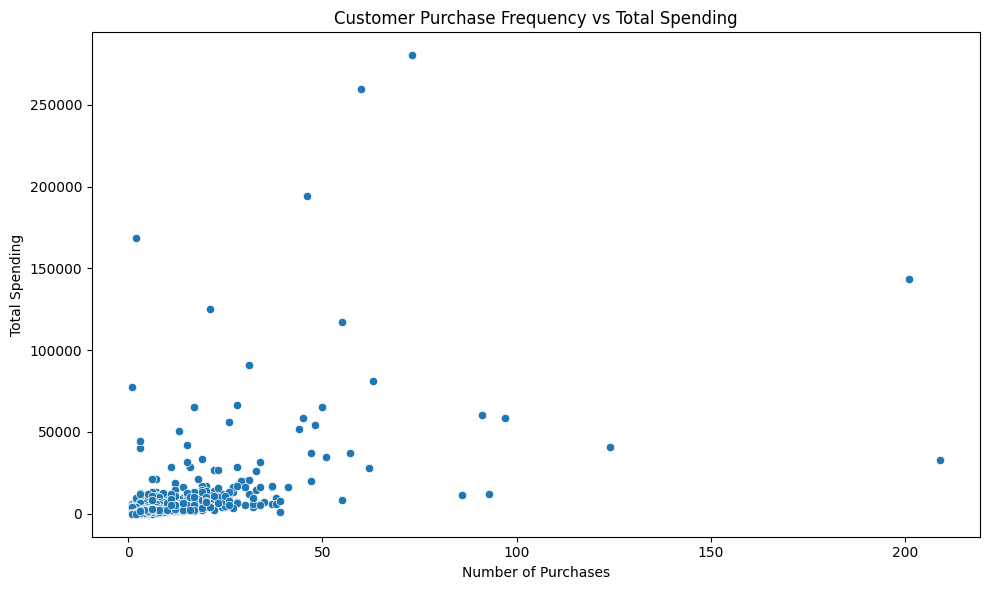

In [19]:
# Customer behavior relationship
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="NumPurchases",
    y="TotalSpending"
)

plt.title("Customer Purchase Frequency vs Total Spending")
plt.xlabel("Number of Purchases")
plt.ylabel("Total Spending")
plt.tight_layout()

plt.savefig(
    "customer_purchase_frequency_vs_total_spending.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 1000x600 with 0 Axes>

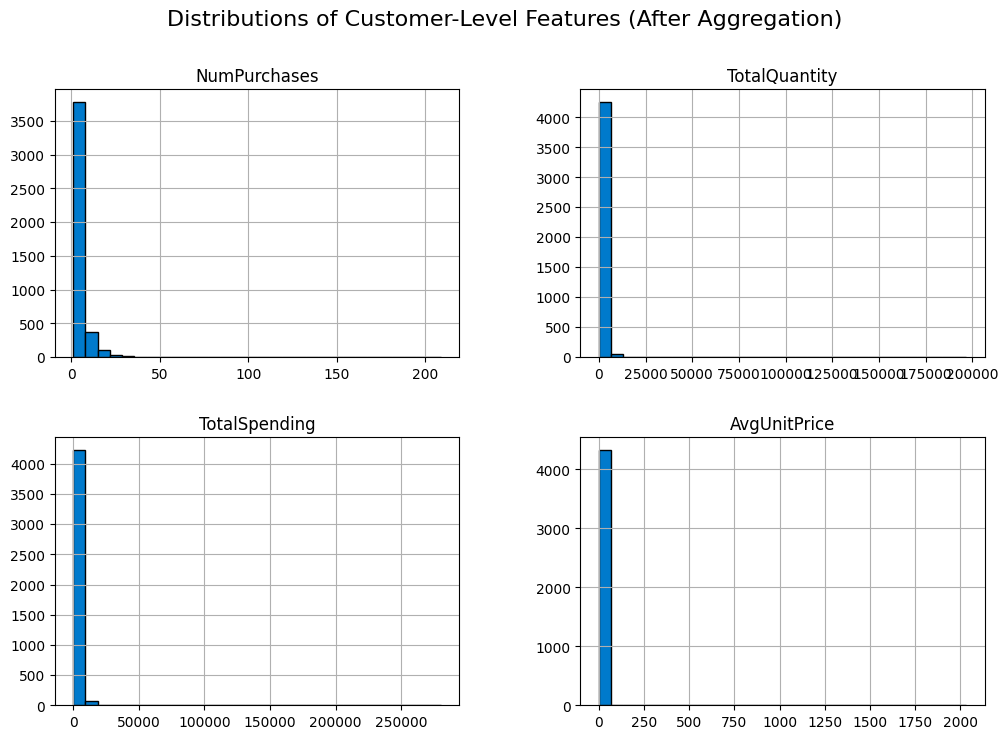

In [20]:
# Summary (Distribution of key features after aggregation
plt.figure(figsize=(10,6))
df[['NumPurchases', 'TotalQuantity', 'TotalSpending', 'AvgUnitPrice']].hist(
    bins=30, figsize=(12,8), color='#007acc', edgecolor='black'
)
plt.suptitle("Distributions of Customer-Level Features (After Aggregation)", fontsize=16)
plt.show()


## Key Findings

The exploratory analysis highlights several patterns relevant to the
subsequent personalization workflow:

- Customer purchasing behaviour varies substantially across the dataset.
- Customer spending and purchase frequency show differences that can
  support behavioural segmentation.
- Product demand is uneven, with a smaller number of products accounting
  for a significant share of purchases.
- The observed behavioural differences provide a basis for constructing
  customer-level features for clustering and recommendation modelling.

These findings motivate the customer segmentation stage in Notebook 03.

## Product Relevance

The exploratory analysis provides evidence that customer behaviour can
be differentiated using transaction-level information.

From a product perspective, these insights can support:

- Customer segmentation
- Personalized product discovery
- Cross-selling and upselling
- Customer retention analysis
- Recommendation strategy
- Data-driven product decisions

The findings are used to inform the customer segmentation and
recommendation stages of the project.